#Credit Card Fraud Detection using Machine Learning

Credit card fraud detection is an important application of machine learning in the financial sector. Fraudulent transactions can cause significant financial losses for banks and customers, so detecting them quickly is essential.

In this project, a machine learning model is built to classify credit card transactions as fraudulent or legitimate using transaction data. Algorithms such as Logistic Regression, Decision Tree, and Random Forest are used to train and evaluate the model to identify suspicious transactions accurately.

#Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Load the Dataset

In [2]:
train_data = pd.read_csv('/content/fraudTrain.csv')
test_data = pd.read_csv('/content/fraudTest.csv')

train_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


#Dataset Information

In [3]:
print("Training Dataset Shape:", train_data.shape)
print("Testing Dataset Shape:", test_data.shape)

train_data.info()

Training Dataset Shape: (73924, 23)
Testing Dataset Shape: (217270, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73924 entries, 0 to 73923
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             73924 non-null  int64  
 1   trans_date_trans_time  73924 non-null  object 
 2   cc_num                 73924 non-null  int64  
 3   merchant               73924 non-null  object 
 4   category               73924 non-null  object 
 5   amt                    73924 non-null  float64
 6   first                  73924 non-null  object 
 7   last                   73924 non-null  object 
 8   gender                 73924 non-null  object 
 9   street                 73924 non-null  object 
 10  city                   73923 non-null  object 
 11  state                  73923 non-null  object 
 12  zip                    73923 non-null  float64
 13  lat                    73923 non-n

In [4]:
train_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


#Data Preprocessing
**Check Fraud vs Legitimate Transactions**

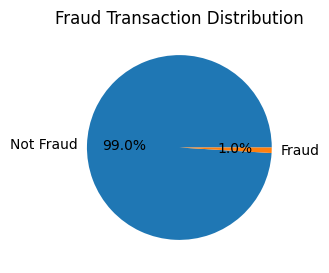

In [11]:
fraud_counts = train_data['is_fraud'].value_counts()

plt.figure(figsize=(3,3))
plt.pie(fraud_counts, labels=['Not Fraud','Fraud'], autopct='%1.1f%%')
plt.title("Fraud Transaction Distribution")
plt.show()

**Feature Selection**

In [12]:
X = train_data.drop('is_fraud', axis=1)
y = train_data['is_fraud']

In [13]:
X = train_data.select_dtypes(include=['int64','float64']).drop('is_fraud', axis=1)
y = train_data['is_fraud']

#Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model Training – Logistic Regression

In [16]:
X = X.dropna()
y = y[X.index]

In [18]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Model Prediction**

In [19]:
y_pred = log_model.predict(X_test)

#Model Accuracy

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 99.11%


#Model Evaluation
**Confusion Matrix**

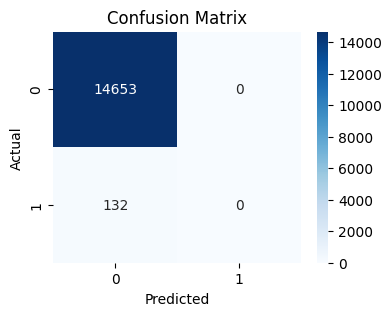

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Decision Tree**

In [23]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [24]:
y_pred_dt = dt_model.predict(X_test)

In [25]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy: {:.2f}%".format(accuracy_dt * 100))

Decision Tree Accuracy: 99.16%


Decision Tree Confusion Matrix

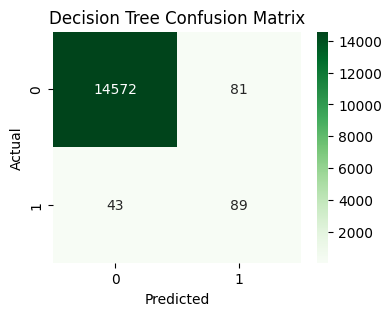

In [26]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(4,3))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Random Forest**

In [27]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [28]:
y_pred_rf = rf_model.predict(X_test)

In [29]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy: {:.2f}%".format(accuracy_rf * 100))

Random Forest Accuracy: 99.55%


**Random Forest Confusion Matrix**

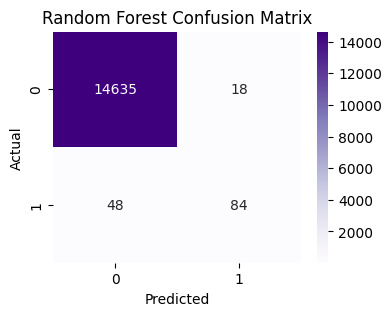

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Conclusion

This project built a machine learning model to detect fraudulent credit card transactions. Logistic Regression, Decision Tree, and Random Forest algorithms were trained and evaluated.

The models successfully classified transactions as fraud or legitimate, and Random Forest achieved the best performance. This demonstrates how machine learning can help improve fraud detection in financial systems.